In [1]:
# Import
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# Authenticate
ee.Authenticate()

True

In [3]:
# Initialize
PROJECT_ID = 'ee-xinranzhou2059'   # ⚠️ replace this

ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine initialized — project: {PROJECT_ID}")

✅ Earth Engine initialized — project: ee-xinranzhou2059


In [4]:
lat_north = 40.7666667
lat_south = 39.4833333
lon_west = -105.4666667
lon_east = -105.05



study_area = ee.Geometry.Rectangle([
[lon_west, lat_south], # SW
[lon_east, lat_north] # NE
])



Map = geemap.Map(center=[(lat_north+lat_south)/2, (lon_west+lon_east)/2], zoom=9)
Map.addLayer(study_area, {'color': 'red'}, 'Study Area Rectangle')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [13]:
nlcd_2001 = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2001'))
             .first().select('landcover').clip(study_area))

nlcd_2021 = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2021'))
             .first().select('landcover').clip(study_area))

# GEE knows NLCD's color palette — no vis_params needed
Map5 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map5.split_map(
    left_layer=geemap.ee_tile_layer(nlcd_2001, {}, 'NLCD 2001'),
    right_layer=geemap.ee_tile_layer(nlcd_2021, {}, 'NLCD 2021')
)
Map5.add_legend(title='NLCD Land Cover', builtin_legend='NLCD')
show_map(Map5)

Map(center=[40.125, -105.25833335], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [14]:
counts_2001 = (
    nlcd_2001
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

counts_2021 = (
    nlcd_2021
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

print("2001 raw NLCD class counts:", counts_2001)
print("2021 raw NLCD class counts:", counts_2021)

2001 raw NLCD class counts: {'11': 104948.72156862746, '21': 278222.6549019608, '22': 364883.6039215686, '23': 212638.86274509807, '24': 60943.05098039215, '31': 6736.96862745098, '41': 69570.41960784313, '42': 2167103.156862742, '43': 9023.368627450982, '52': 1012100.7294117647, '71': 851773.6039215686, '81': 103421.78039215687, '82': 221813.87058823527, '90': 72401.03921568628, '95': 87508.36470588237}
2021 raw NLCD class counts: {'11': 111299.70588235294, '21': 327438.79215686274, '22': 391609.84705882345, '23': 272557.17254901974, '24': 80177.27843137256, '31': 5714.058823529412, '41': 64902.45098039215, '42': 1744347.5215686248, '43': 8708.372549019608, '52': 1135103.454901961, '71': 1041375.8549019608, '81': 101650.19215686273, '82': 192132.7921568627, '90': 66644.39607843137, '95': 79428.30588235296}


<Axes: title={'center': 'NLCD Land Cover Change (2001 → 2021)'}, xlabel='Category'>

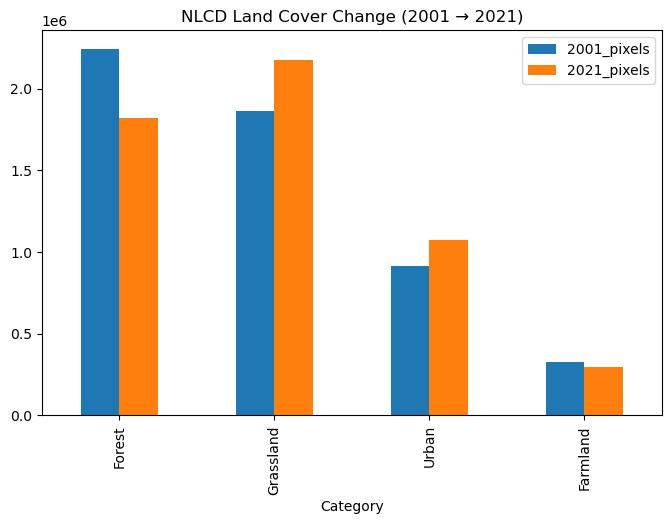

In [44]:
# Category → NLCD class codes
CATEGORIES = {
    "Forest": [41, 42, 43],
    "Grassland": [52, 71, 72],
    "Urban": [21, 22, 23, 24],
    "Farmland": [81, 82]
}

def summarize_categories(counts_dict):
    """Convert raw NLCD class histogram into grouped category totals."""
    summary = {}
    for cat, codes in CATEGORIES.items():
        summary[cat] = sum(counts_dict.get(str(code), 0) for code in codes)
    return summary

summary_2001 = summarize_categories(counts_2001)
summary_2021 = summarize_categories(counts_2021)

df = pd.DataFrame({
    "Category": list(CATEGORIES.keys()),
    "2001_pixels": [summary_2001[c] for c in CATEGORIES],
    "2021_pixels": [summary_2021[c] for c in CATEGORIES],
})

df["Change_pixels"] = df["2021_pixels"] - df["2001_pixels"]
df["Change_percent"] = 100 * df["Change_pixels"] / df["2001_pixels"]
df

df.set_index("Category")[["2001_pixels", "2021_pixels"]].plot.bar(
    figsize=(8,5), title="NLCD Land Cover Change (2001 → 2021)"
)

In [46]:
# Convert pixel counts to area in hectares
# NLCD pixel size = 30 m × 30 m = 900 m² = 0.09 ha

PIXEL_AREA_HA = 0.09

df["2001_area_ha"] = df["2001_pixels"] * PIXEL_AREA_HA
df["2021_area_ha"] = df["2021_pixels"] * PIXEL_AREA_HA
df["Change_area_ha"] = df["2021_area_ha"] - df["2001_area_ha"]

# Optional: convert hectares to square kilometers
df["2001_area_km2"] = df["2001_area_ha"] / 100
df["2021_area_km2"] = df["2021_area_ha"] / 100
df["Change_area_km2"] = df["Change_area_ha"] / 100

# Reorder columns for clearer display
area_change_df = df[
    [
        "Category",
        "2001_area_ha",
        "2021_area_ha",
        "Change_area_ha",
        "Change_percent",
        "2001_area_km2",
        "2021_area_km2",
        "Change_area_km2"
    ]
]

area_change_df.round(2)

,Category,2001_area_ha,2021_area_ha,Change_area_ha,Change_percent,2001_area_km2,2021_area_km2,Change_area_km2
0,Forest,202112.73,163616.25,-38496.47,-19.05,2021.13,1636.16,-384.96
1,Grassland,167748.69,195883.14,28134.45,16.77,1677.49,1958.83,281.34
2,Urban,82501.94,96460.48,13958.54,16.92,825.02,964.60,139.59
3,Farmland,29271.21,26440.47,-2830.74,-9.67,292.71,264.40,-28.31


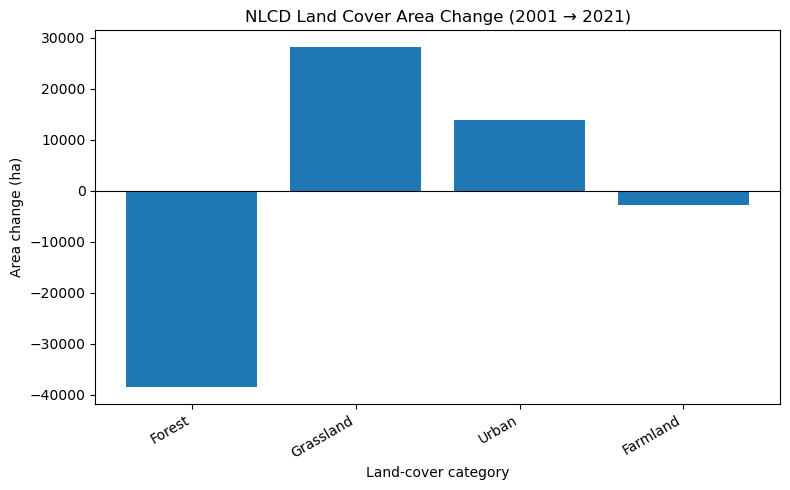

✅ Saved -> figures/nlcd_area_change_2001_2021.png


In [47]:
# Plot area change from 2001 to 2021

plt.figure(figsize=(8, 5))

plt.bar(
    area_change_df["Category"],
    area_change_df["Change_area_ha"]
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Land-cover category")
plt.ylabel("Area change (ha)")
plt.title("NLCD Land Cover Area Change (2001 → 2021)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "figures/nlcd_area_change_2001_2021.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved -> figures/nlcd_area_change_2001_2021.png")

In [24]:
def apply_scale_factors(image):
    """Convert raw Landsat C2 L2 integers to surface reflectance (0–1)."""
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

# Summer 2016 composite — median of all clear-sky scenes
landsat_2016 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(study_area)
    .filterDate('2010-06-01', '2010-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)
print("✅ Landsat 2016 summer composite loaded!")

✅ Landsat 2016 summer composite loaded!


In [25]:
rgb_vis = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0.0, 'max': 0.3}

# Load Landsat 5 (LT05) Collection 2, Tier 1, Level 2 for summer 1984.
# Landsat 8 (LC08) was not active in 1984, and LM03 in C2L2 format is not available.
landsat_1984_raw = (
    ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') # Changed collection to Landsat 5
    .filterBounds(study_area)
    .filterDate('1984-06-01', '1984-08-31') # Filter for summer 1984
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)

# Alias Landsat 5 true color bands (SR_B3, SR_B2, SR_B1 for Red, Green, Blue)
# to match the 'rgb_vis' dictionary's expected Landsat 8/9 band names (SR_B4, SR_B3, SR_B2).
landsat_1984_rgb = landsat_1984_raw.select(
    ['SR_B3', 'SR_B2', 'SR_B1'],  # Landsat 5 True Color bands
    ['SR_B4', 'SR_B3', 'SR_B2']   # Aliased band names expected by rgb_vis
)

Map1 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map1.addLayer(landsat_1984_rgb, rgb_vis, 'Landsat 1984 — True Color') # Updated title and variable
show_map(Map1)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [26]:
false_color_vis = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0.0, 'max': 0.4}

Map2 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map2.addLayer(landsat_1984_raw, false_color_vis, 'Landsat 1984 — False Color (NIR-Red-Green)')
show_map(Map2)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [27]:
# Landsat 9 launched in 2021 — same sensor as Landsat 8, merge both collections
landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(study_area)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)

Map3 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map3.split_map(
    left_layer=geemap.ee_tile_layer(landsat_1984_rgb, rgb_vis, 'Summer 1984'),
    right_layer=geemap.ee_tile_layer(landsat_2024, rgb_vis, 'Summer 2024')
)
show_map(Map3)

Map(center=[40.125, -105.25833335], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

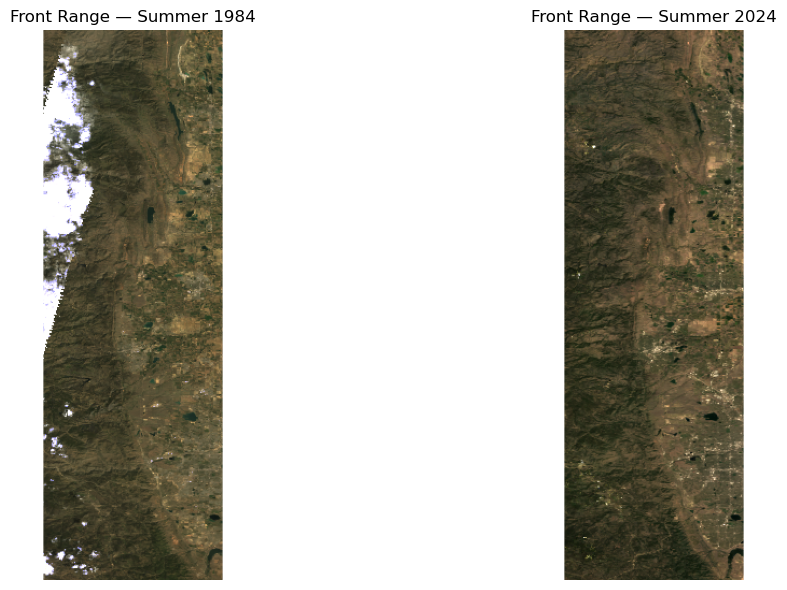

✅ Saved → figures/csu_landsat_comparison.png


In [28]:
import os

def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

thumb_1984 = get_ee_thumbnail(landsat_1984_rgb, rgb_vis, study_area)
thumb_2024 = get_ee_thumbnail(landsat_2024, rgb_vis, study_area)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumb_1984); axes[0].set_title('Front Range — Summer 1984'); axes[0].axis( 'off')
axes[1].imshow(thumb_2024); axes[1].set_title('Front Range — Summer 2024'); axes[1].axis('off')
plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'csu_landsat_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_landsat_comparison.png")

In [29]:
# ✏️ Exercise 1a — winter 2024 composite
winter_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(study_area)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)

Map_winter = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map_winter.addLayer(winter_2024, rgb_vis, 'Landsat 2024 — Winter True Color')
show_map(Map_winter)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [30]:
# ✏️ Exercise 1b — winter false color
Map_winter_false = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map_winter_false.addLayer(winter_2024, false_color_vis, 'Landsat 2024 — Winter False Color (NIR)')
show_map(Map_winter_false)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [31]:
def compute_ndvi(image):
    """Add an NDVI band to a Landsat image."""
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(ndvi)

ndvi_1984 = compute_ndvi(landsat_1984_raw)
ndvi_2024 = compute_ndvi(landsat_2024)

ndvi_vis = {
    'bands': ['NDVI'],
    'min': -0.1, 'max': 0.8,
    'palette': ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#91cf60', '#1a9850']
}

Map4 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map4.addLayer(ndvi_1984, ndvi_vis, 'NDVI 1984')
Map4.addLayer(ndvi_2024, ndvi_vis, 'NDVI 2024')
Map4.add_colorbar(ndvi_vis, label='NDVI')
show_map(Map4)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

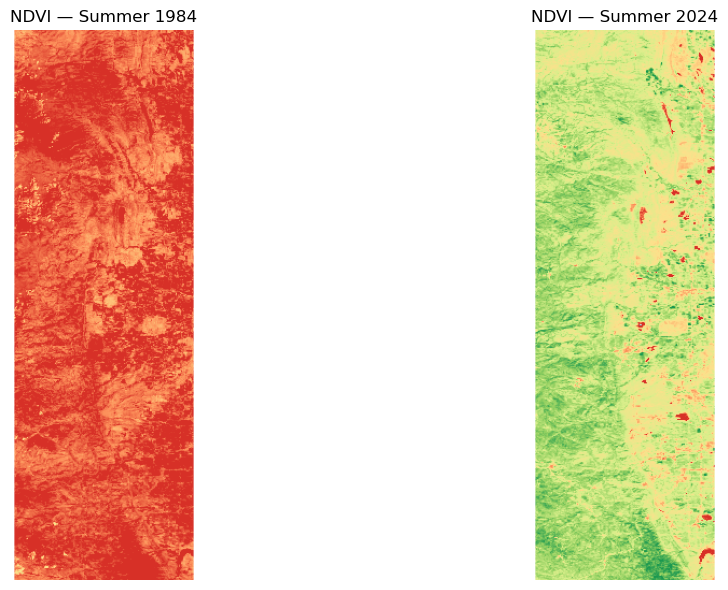

✅ Saved → figures/csu_ndvi_comparison.png


In [32]:
import os

ndvi_thumb_1984 = get_ee_thumbnail(ndvi_1984, ndvi_vis, study_area)
ndvi_thumb_2024 = get_ee_thumbnail(ndvi_2024, ndvi_vis, study_area)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ndvi_thumb_1984); axes[0].set_title('NDVI — Summer 1984'); axes[0].axis('off')
axes[1].imshow(ndvi_thumb_2024); axes[1].set_title('NDVI — Summer 2024'); axes[1].axis('off')
plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'csu_ndvi_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_ndvi_comparison.png")

In [33]:
# Define visualization parameters for the blended RGB uint8 images
uint8_rgb_vis = {'bands': ['red', 'green', 'blue'], 'min': 0, 'max': 255}

# Prepare Landsat 2024 true color image with 'red', 'green', 'blue' bands.
# This ensures consistency for blending and final display.
landsat_2024_rgb = landsat_2024.select(
    ['SR_B4', 'SR_B3', 'SR_B2'],  # Original Landsat 8/9 bands for True Color
    ['red', 'green', 'blue']      # Renamed bands for consistent visualization
)

In [35]:
nlcd_change = nlcd_2001.select('landcover').neq(nlcd_2021.select('landcover'))

# Apply selfMask() to make unchanged areas (value 0) transparent
nlcd_change_masked = nlcd_change.selfMask()

# Define visualization for the changed areas (red). Unchanged areas are now transparent due to selfMask().
change_vis_combined = {'min': 1, 'max': 1, 'palette': ['FF0000']}

# Create a new map
Map_nlcd_change = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)

# Add the Landsat 2024 RGB image as a background
# landsat_2024_rgb is expected to be defined with 'red', 'green', 'blue' bands and uint8_rgb_vis works with it.
Map_nlcd_change.addLayer(landsat_2024_rgb, uint8_rgb_vis, 'Landsat 2024 True Color')

# Overlay the NLCD change areas (only changed areas will be visible)
Map_nlcd_change.addLayer(nlcd_change_masked, change_vis_combined, 'NLCD Land Cover Change (2001-2021)')

# Add a legend for the change layer
Map_nlcd_change.add_legend(title='Land Cover Status',
                           legend_keys=['Changed Area', 'Unchanged Area (Transparent)'],
                           legend_colors=['#FF0000', 'transparent'])

show_map(Map_nlcd_change)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

Burned pixels from 2001-2021 (MODIS): 3072.996078431373


Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

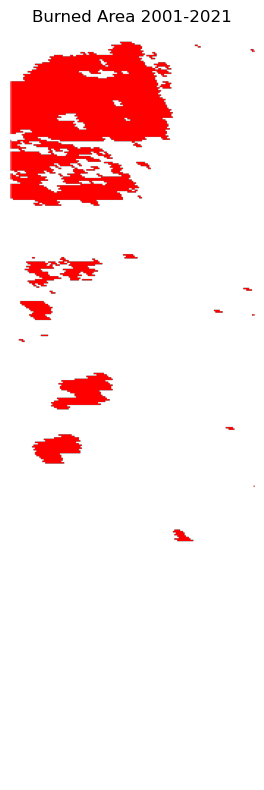

✅ Saved → figures/burned_area_2001_2021.png


In [36]:
import os

# Load MODIS burned area data for the entire period 2001-2021
burned_area_2001_2021 = (ee.ImageCollection('MODIS/061/MCD64A1')
                            .filterDate('2001-01-01', '2021-12-31')
                            .select('BurnDate')
                            .max() # Use max to get any burn within the period
                            .gt(0)
                            .selfMask()
                            .clip(study_area))

# Calculate and print the total number of burned pixels for the period
pixel_count_2001_2021 = burned_area_2001_2021.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=study_area,
    scale=500, # MODIS resolution is 500m
    maxPixels=1e9
).get('BurnDate').getInfo()

print(f"Burned pixels from 2001-2021 (MODIS): {pixel_count_2001_2021 if pixel_count_2001_2021 else 0}")

# Define visualization parameters for burned areas (red)
fire_vis = {'palette': ['ff0000']}

# Create a map to display aggregated burned areas
Map_fire_aggregated = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map_fire_aggregated.addLayer(burned_area_2001_2021, fire_vis, 'Burned Area 2001-2021')

# Add a legend for the fire data
Map_fire_aggregated.add_legend(title='Burned Area', legend_keys=['Burned'], legend_colors=['#ff0000'])

show_map(Map_fire_aggregated)

# Save the map as a static image
fire_thumb_aggregated = get_ee_thumbnail(burned_area_2001_2021, fire_vis, study_area)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(fire_thumb_aggregated)
ax.set_title('Burned Area 2001-2021')
ax.axis('off')
plt.tight_layout()

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'burned_area_2001_2021.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved → figures/burned_area_2001_2021.png')

In [37]:
def count_classes(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for an NLCD image."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']
    print(f"\n--- NLCD {year} (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        print(f"  Class {code}: {n:,} pixels")
    return counts

counts_2001 = count_classes(nlcd_2001, 2001)
counts_2021 = count_classes(nlcd_2021, 2021)


--- NLCD 2001 (top classes) ---
  Class 42: 2,167,103.156862742 pixels
  Class 52: 1,012,100.7294117647 pixels
  Class 71: 851,773.6039215686 pixels
  Class 22: 364,883.6039215686 pixels
  Class 21: 278,222.6549019608 pixels
  Class 82: 221,813.87058823527 pixels
  Class 23: 212,638.86274509807 pixels
  Class 11: 104,948.72156862746 pixels

--- NLCD 2021 (top classes) ---
  Class 42: 1,744,347.5215686248 pixels
  Class 52: 1,135,103.454901961 pixels
  Class 71: 1,041,375.8549019608 pixels
  Class 22: 391,609.84705882345 pixels
  Class 21: 327,438.79215686274 pixels
  Class 23: 272,557.17254901974 pixels
  Class 82: 192,132.7921568627 pixels
  Class 11: 111,299.70588235294 pixels


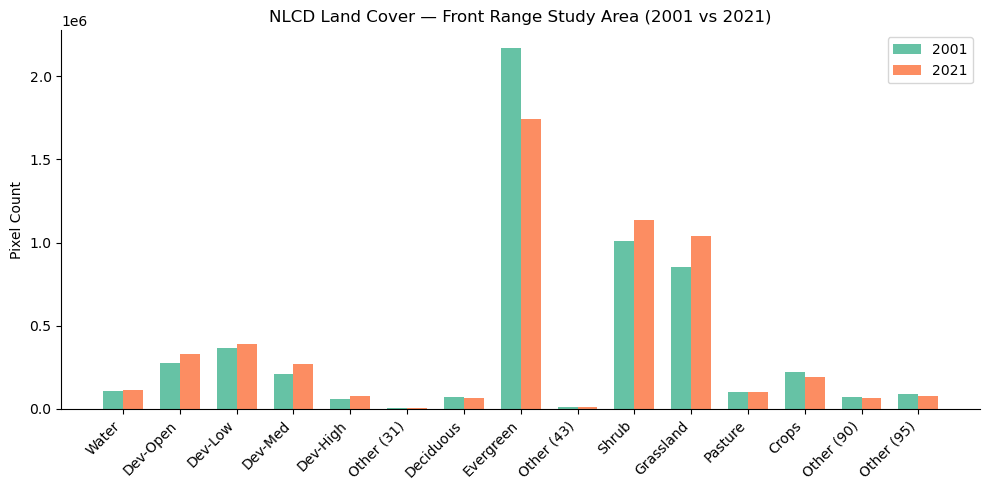

✅ Saved → figures/csu_nlcd_comparison.png


In [38]:
import pandas as pd

# Bar chart: 2001 vs 2021 side by side
nlcd_names = {
    '11':'Water','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '41':'Deciduous','42':'Evergreen','52':'Shrub','71':'Grassland',
    '81':'Pasture','82':'Crops'
}
all_classes = sorted(set(counts_2001) | set(counts_2021))
df = pd.DataFrame({
    'Class': [nlcd_names.get(c, f'Other ({c})') for c in all_classes],
    '2001':  [counts_2001.get(c, 0) for c in all_classes],
    '2021':  [counts_2021.get(c, 0) for c in all_classes],
})

fig, ax = plt.subplots(figsize=(10, 5))
x, w = range(len(df)), 0.35
ax.bar([i - w/2 for i in x], df['2001'], w, label='2001', color='#66c2a5')
ax.bar([i + w/2 for i in x], df['2021'], w, label='2021', color='#fc8d62')
ax.set_xticks(x); ax.set_xticklabels(df['Class'], rotation=45, ha='right')
ax.set_ylabel('Pixel Count')
ax.set_title('NLCD Land Cover — Front Range Study Area (2001 vs 2021)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_nlcd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_nlcd_comparison.png")

In [39]:
# ✏️ Exercise 3a — 5 km AOI class counts
csu_wide = ee.Geometry.Point([(lon_west + lon_east) / 2, (lat_north + lat_south) / 2]).buffer(5000).bounds()

nlcd_2001_wide = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
                  .filter(ee.Filter.eq('system:index', '2001'))
                  .first().select('landcover').clip(csu_wide))

nlcd_2021_wide = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
                  .filter(ee.Filter.eq('system:index', '2021'))
                  .first().select('landcover').clip(csu_wide))

counts_2001_wide = count_classes(nlcd_2001_wide, 2001)
counts_2021_wide = count_classes(nlcd_2021_wide, 2021)

print('\nWide AOI summary:')
print('Crops 2001:', counts_2001_wide.get('82', 0), 'Crops 2021:', counts_2021_wide.get('82', 0))
print('Pasture 2001:', counts_2001_wide.get('81', 0), 'Pasture 2021:', counts_2021_wide.get('81', 0))


--- NLCD 2001 (top classes) ---
  Class 71: 48,438.8 pixels
  Class 52: 21,368.87058823528 pixels
  Class 42: 13,653.341176470585 pixels
  Class 81: 8,441.603921568625 pixels
  Class 21: 6,717.690196078427 pixels
  Class 95: 4,041.000000000001 pixels
  Class 11: 2,503.83137254902 pixels
  Class 22: 2,153.13725490196 pixels

--- NLCD 2021 (top classes) ---
  Class 71: 55,088.207843137265 pixels
  Class 52: 21,146.223529411756 pixels
  Class 81: 9,060.125490196075 pixels
  Class 21: 6,847.874509803918 pixels
  Class 42: 6,743.831372549021 pixels
  Class 95: 4,007.6666666666674 pixels
  Class 11: 2,290.525490196079 pixels
  Class 22: 2,214.5647058823524 pixels

Wide AOI summary:
Crops 2001: 1046.2039215686277 Crops 2021: 1191.5843137254901
Pasture 2001: 8441.603921568625 Pasture 2021: 9060.125490196075


In [40]:
# ✏️ Exercise 3b — largest increase and decrease
delta_counts = {cls: counts_2021.get(cls, 0) - counts_2001.get(cls, 0)
                for cls in set(counts_2001) | set(counts_2021)}

largest_gain = max(delta_counts.items(), key=lambda item: item[1])
largest_loss = min(delta_counts.items(), key=lambda item: item[1])

nlcd_names = {
    '11':'Water','12':'Perennial Ice/Snow','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '31':'Barren Land','41':'Deciduous','42':'Evergreen','43':'Mixed Forest','52':'Shrub',
    '71':'Grassland','81':'Pasture','82':'Crops','90':'Woody Wetlands','95':'Emergent Herbaceous Wetlands'
}

print('Largest increase:', nlcd_names.get(largest_gain[0], largest_gain[0]), largest_gain[1])
print('Largest decrease:', nlcd_names.get(largest_loss[0], largest_loss[0]), largest_loss[1])

Largest increase: Grassland 189602.25098039221
Largest decrease: Evergreen -422755.63529411703


In [43]:
# Using 'study_area' for clipping and map setup.

dem = ee.Image('USGS/3DEP/10m').clip(study_area)

elev_vis = {
    'min': 1500, 'max': 2200,
    'palette': ['#2b83ba', '#abdda4', '#ffffbf', '#fdae61', '#d7191c']
}

Map6 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map6.addLayer(dem, elev_vis, 'Elevation (m)')
Map6.add_colorbar(elev_vis, label='Elevation (m)')
show_map(Map6)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…